# Excitation 1s3 level

In [2]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

## Read LXCat cross-section datasets

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

## Read experimental measurement datasets

In [4]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Preparation of datasets used for Bayesian inference

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
True
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
True
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
True
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). M

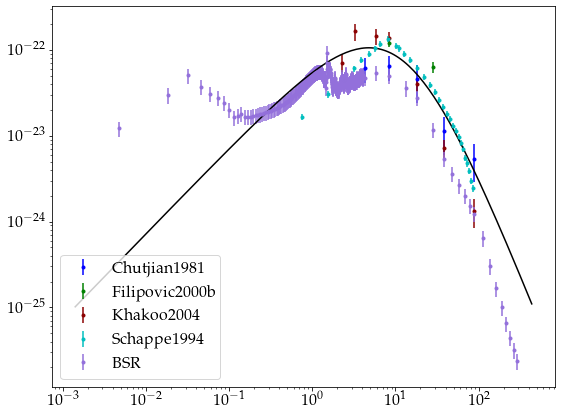

In [5]:
from models import *
level = 3
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.1s%d.txt' % (refs[k], 6-level)
        np.savetxt(filename, temp)
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
        
        filename = '%s.1s%d.txt' % ('BSR', 6-level)
        np.savetxt(filename, temp)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
# theta_ref = np.array([10.4e0,2.0])
theta_ref = np.array([2.0e0,1.45])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)

temp = np.append(Etest[...,None], model0[...,None], axis=1)
filename = '%s.1s%d.naive.txt' % ('Bretagne', 6-level)
np.savetxt(filename, temp)

mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


## Log-scaling of datasets
## Pre-processing of datasets for Gaussian-process kernel

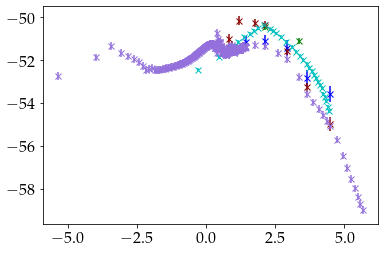

In [6]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

## Initializing a Gaussian-process kernel
A homo-schedastic Matern kernel.

## probability functions for Bayesian inference

In [249]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([10.4e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


## Setting up the MCMC sampler

In [250]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4e0,2.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

## Run the MCMC sampling

In [251]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  1%|▋                                                     | 6/500 [00:00<00:17, 28.57it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_83655/844000950.py:36: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.15it/s]


[27.78766669 27.36509584 27.69779442 42.0780578 ]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 27.86it/s]


[34.17228154 32.50256717 38.30232251 47.69991695]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.60it/s]


...

[55.10427264 48.61495036 69.27000842 64.97837776]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 29.19it/s]


[56.10788281 49.91317953 69.02601726 65.38838597]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.95it/s]


[58.47552485 50.93001836 70.90586562 65.30369068]


## Post-process of the resulting samples

(6208, 4)


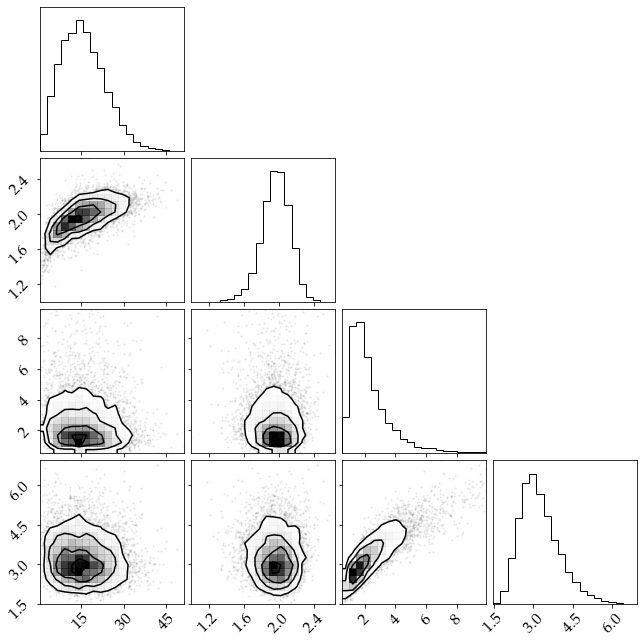

In [252]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

## Resulting cross-section samples

/opt/homebrew/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


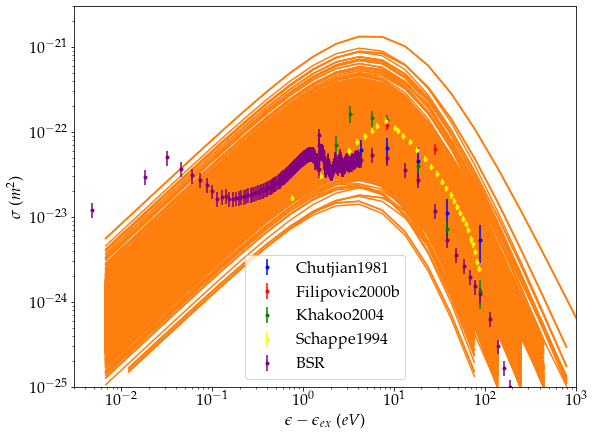

In [82]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=7200)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
#     models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

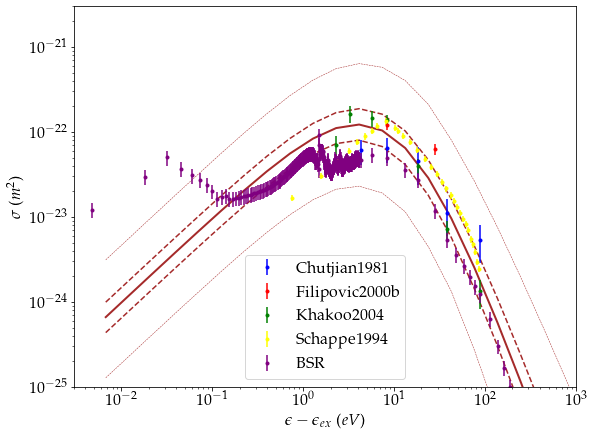

In [88]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nsample, Nw = flat_samples.shape[0], 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
sample_curves = np.zeros([Nsample, Nw])
sig1 = int(np.floor(Nsample * 0.5 * (1.0 - 0.68)))
sig3 = int(np.floor(Nsample * 0.5 * (1.0 - 0.997)))
median = int(np.floor(Nsample * 0.5))

for ind in range(Nsample):
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
    sample_curves[ind,:] = models

sample_sort = np.copy(sample_curves)
sample_sort.sort(axis=0)

plt.figure(1)
plt.loglog(Etest-E_ext[level-1], sample_sort[sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[median,:], '-', linewidth=2.0, color='brown')
    
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

temp = np.zeros([Nw,6])
temp[:,0] = Etest
temp[:,1] = sample_sort[median,:]
temp[:,2] = sample_sort[sig1,:]
temp[:,3] = sample_sort[-sig1,:]
temp[:,4] = sample_sort[sig3,:]
temp[:,5] = sample_sort[-sig3,:]
filename = './1s%d.sample_crs.txt' % ((6-level))
np.savetxt(filename, temp)

## Excitation 1s3 level, Bayesian inference from individual datasets

In [78]:
from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    theta_ref = np.array([10.4e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
        
    return lp


def log_likelihood(theta):
    lk = 0.0
    for k in range(len(Wlog)):
#         if (k!=4): continue
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        lk += - 0.5 * np.sum(dev * dev / ed[k] / ed[k])
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [79]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4e0,2.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [81]:
# sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 314.62it/s]


[39.99963136 47.90687254]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 314.52it/s]


[39.96414447 47.66936935]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 305.96it/s]


...

[39.88872592 46.78301612]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 320.23it/s]


[39.90076065 46.73061505]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 296.94it/s]


[39.88953915 46.66754555]


(16672, 2)


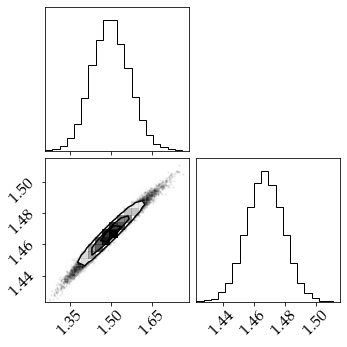

In [83]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-individual/All.1s3.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

wgk max: 4.379751307856772E-03
0.029082511505437867
0.029593990284485217
0.015184125212878829
0.2392622379544344
0.15218935404731693
0.3039988246528539
histw max: 4.136333096260930E-03


/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16632/2084633420.py:71: UserWarning: Trying to register the cmap 'BlueAlphaMap' which already exists.
  plt.register_cmap(cmap=blueMap)
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16632/2084633420.py:98: UserWarning: Trying to register the cmap 'colorMap0' which already exists.
  plt.register_cmap(cmap=cMap)
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16632/2084633420.py:98: UserWarning: Trying to register the cmap 'colorMap1' which already exists.
  plt.register_cmap(cmap=cMap)
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16632/2084633420.py:98: UserWarning: Trying to register the cmap 'colorMap2' which already exists.
  plt.register_cmap(cmap=cMap)
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16632/2084633420.py:98: UserWarning: Trying to register the cmap 'colorMap3' which already exists.
  plt.register_cmap(cmap=cMap)
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/

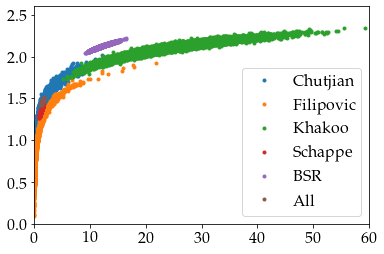

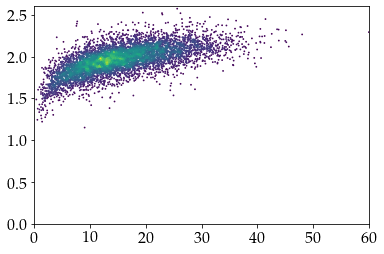

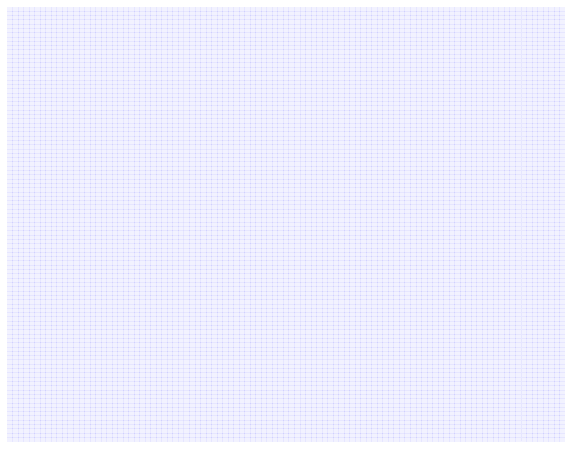

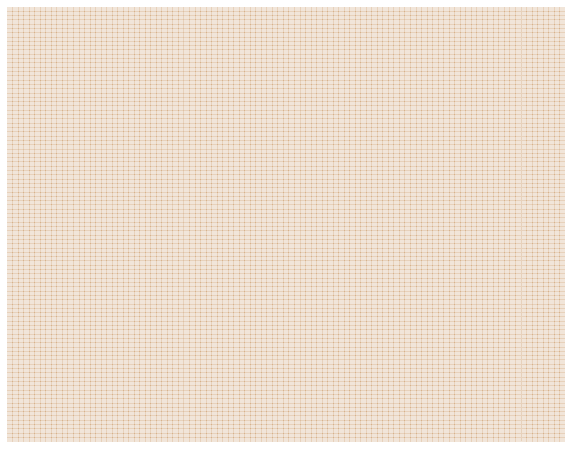

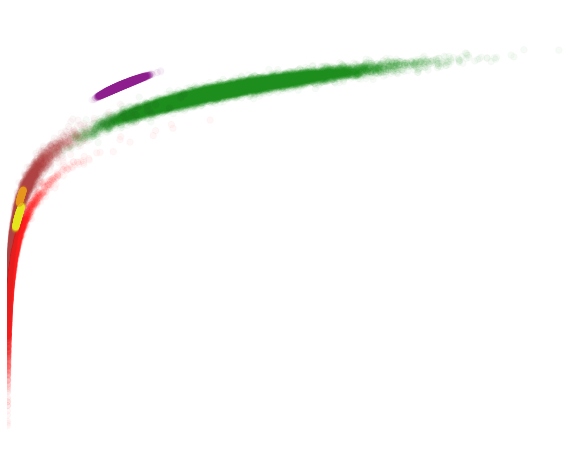

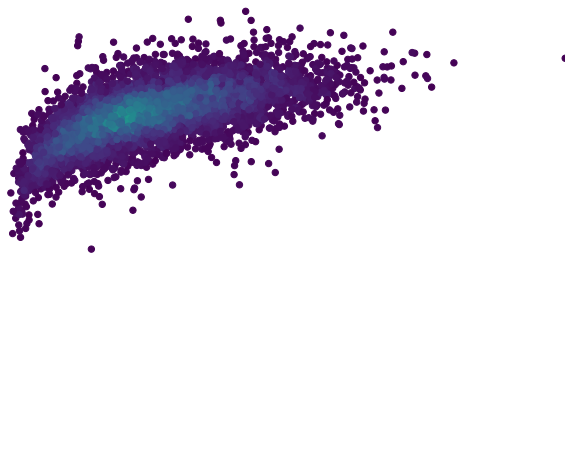

In [12]:
from interp import histogram_weight_2d
names = ['Chutjian','Filipovic','Khakoo','Schappe','BSR','All']

xlim = [0.0, 60.0]
ylim = [0.0, 2.5]
Nx, Ny = 100, 100
xg = np.linspace(xlim[0],xlim[1],Nx+1)
yg = np.linspace(ylim[0],ylim[1],Ny+1)

YG, XG = np.meshgrid(yg,xg)

flat_samples = []
wg = []
for k in range(6):
    temp = np.fromfile('../crs-Bayes-individual/%s.1s3.dat' % names[k])
    temp = np.reshape(temp, [int(len(temp)/2), 2])
    histw, wgk = histogram_weight_2d(temp[:,0],temp[:,1],Nx,Ny,xlim,ylim)
    wg += [np.copy(wgk)]
    temp = np.append(temp, histw[...,None], axis=1)
    flat_samples += [temp]
    
gpr_sample = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
gpr_sample = np.reshape(gpr_sample, [int(len(gpr_sample)/4), 4])
histw, wgk = histogram_weight_2d(gpr_sample[:,0],gpr_sample[:,1],Nx,Ny,xlim,ylim)
print('wgk max: %.15E' % np.amax(wgk))
wg += [np.copy(wgk)]
gpr_sample = np.append(gpr_sample, histw[...,None], axis=1)
    
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
plt.figure(1)
# plt.plot(gpr_sample[:,0], gpr_sample[:,1],'.')
for k in range(6):
    print(np.amax(flat_samples[k][:,2]))
#     plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=0.4, c=flat_samples[k][:,2],label=names[k])
    plt.plot(flat_samples[k][:,0], flat_samples[k][:,1],'.',label=names[k])
plt.xlim([0, 60])
plt.ylim([0, 2.6])
plt.legend()

print("histw max: %.15E" % np.amax(gpr_sample[:,4]))
plt.figure(2)
plt.scatter(gpr_sample[:,0], gpr_sample[:,1],s=0.6, c=gpr_sample[:,4])
plt.xlim([0, 60])
plt.ylim([0, 2.6])

# for k in range(6):
#     print(flat_samples[k].shape)
#     filename = '%s.1s3.param.txt' % (names[k])
#     np.savetxt(filename, flat_samples[k])
    
# gpr_data = gpr_sample[:,[0,1,4]]
# filename = 'GPR.1s3.param.txt'
# np.savetxt(filename, gpr_data)

blueDict = {'red': ((0.0, 0.0, 0.0),
                    (1.0, 0.0, 0.0)),
            'green': ((0.0, 0.0, 0.0),
                      (1.0, 0.0, 0.0)),
            'blue': ((0.0, 1.0, 1.0),
                     (1.0, 1.0, 1.0)),
            'alpha': ((0.0, 0.05, 0.05),
                      (1.0, 0.05, 0.05))
           }
from matplotlib.colors import LinearSegmentedColormap, to_rgba
blueMap = LinearSegmentedColormap('BlueAlphaMap', blueDict)
plt.register_cmap(cmap=blueMap)


plt.figure(3)
plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.gpr.pdf", dpi=600, bbox_inches='tight')
# fig.savefig("./1s3.gpr.png", dpi=600, bbox_inches='tight')

colors = ['brown','red','green','yellow','purple','orange']
for k in range(6):
    colork = to_rgba(colors[k])
    cDict = {'red': ((0.0, colork[0], colork[0]),
                     (1.0, colork[0], colork[0])),
             'green': ((0.0, colork[1], colork[1]),
                       (1.0, colork[1], colork[1])),
             'blue': ((0.0, colork[2], colork[2]),
                      (1.0, colork[2], colork[2])),
#              'alpha': ((0.0, 0.006, 0.006),
#                        (1.0, 0.006, 0.006))
             'alpha': ((0.0, 0.03, 0.03),
                       (1.0, 0.03, 0.03))
            }
    cMap = LinearSegmentedColormap('colorMap%d' % k, cDict)
    plt.register_cmap(cmap=cMap)
    
plt.figure(4)
for k in range(6):
    plt.pcolor(XG,YG,wg[k],edgecolor='none',cmap='colorMap%d' % k)
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.naive.pdf", dpi=600, bbox_inches='tight')

plt.figure(5)
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)
#     plt.plot(flat_samples[k][:,0], flat_samples[k][:,1],'.',label=names[k])
plt.xlim([0, 60])
plt.ylim([0, 2.6])
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.naive.scatter.pdf", dpi=600, bbox_inches='tight')

plt.figure(6)
# for k in range(6):
#     plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)
# plt.scatter(gpr_sample[:,0], gpr_sample[:,1],s=40.0, c=gpr_sample[:,4], cmap='BlueAlphaMap')
plt.scatter(gpr_sample[:,0], gpr_sample[:,1],s=40.0, c=gpr_sample[:,4])
# plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
plt.xlim([0, 60])
plt.ylim([0, 2.6])
plt.clim(0, 6.7e-3)
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
fig.savefig("./1s3.gpr.scatter.new.pdf", dpi=600, bbox_inches='tight')